# Import Libraries

In [1]:
import sys, os

# Add path to import
sys.path.append(os.path.abspath(".."))

In [2]:
from src.forecasting.utils.libraries_data_handling import pd, np
from src.forecasting.utils.libraries_others import re, os, time
from src.forecasting.utils.libraries_plotting import plt
from src.forecasting.utils.libraries_modelling import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from src.forecasting.constants.columns import col_decode, col_encode
from src.forecasting.constants.enums import ColumnGroup, PeriodList
from src.forecasting.constants.color import color_variant

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
/home/jovyan/work/3012010008/env_3012010008/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Backtesting Results

In [3]:
# Load TFT backtesting results
tft_backtesting = (
    pd.read_excel('../data/predicted/tft_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

print('Before cut timestamp:')
print('TFT backtesting starts:\t', tft_backtesting.index.min())
print('TFT backtesting ends:\t', tft_backtesting.index.max())

## ========================= CUT TIMESTAMP ========================= ##
# Start at 09:00
backtesting_start = tft_backtesting.index[tft_backtesting.index.hour == 9][0]
tft_backtesting   = tft_backtesting.loc[backtesting_start:]

# End at 08:00
backtesting_end  = tft_backtesting.index[tft_backtesting.index.hour == 8][-1]
tft_backtesting  = tft_backtesting.loc[:backtesting_end]

print('\nAfter cut timestamp:')
print('TFT backtesting starts:\t', tft_backtesting.index.min())
print('TFT backtesting ends:\t', tft_backtesting.index.max())

print('\nInfo:')
print(tft_backtesting.info())

Before cut timestamp:
TFT backtesting starts:	 2025-03-17 08:00:00
TFT backtesting ends:	 2025-06-30 23:00:00

After cut timestamp:
TFT backtesting starts:	 2025-03-17 09:00:00
TFT backtesting ends:	 2025-06-30 08:00:00

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2520 entries, 2025-03-17 09:00:00 to 2025-06-30 08:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2520 non-null   float64
 1   y2_actual  2520 non-null   float64
 2   y3_actual  2520 non-null   int64  
 3   y4_actual  2520 non-null   float64
 4   y5_actual  2520 non-null   float64
 5   y1_pred    2520 non-null   float64
 6   y2_pred    2520 non-null   float64
 7   y3_pred    2520 non-null   float64
 8   y4_pred    2520 non-null   float64
 9   y5_pred    2520 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 216.6 KB
None


In [4]:
# Load N-BEATS backtesting results
nbeats_backtesting = (
    pd.read_excel('../data/predicted/nbeats_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

print('Before cut timestamp:')
print('N-BEATS backtesting starts:\t', nbeats_backtesting.index.min())
print('N-BEATS backtesting ends:\t', nbeats_backtesting.index.max())

## ========================= CUT TIMESTAMP ========================= ##
# Start at 09:00
backtesting_start = nbeats_backtesting.index[nbeats_backtesting.index.hour == 9][0]
nbeats_backtesting   = nbeats_backtesting.loc[backtesting_start:]

# End at 08:00
backtesting_end  = nbeats_backtesting.index[nbeats_backtesting.index.hour == 8][-1]
nbeats_backtesting  = nbeats_backtesting.loc[:backtesting_end]
## ========================= CUT TIMESTAMP ========================= ##

print('\nAfter cut timestamp:')
print('N-BEATS backtesting starts:\t', nbeats_backtesting.index.min())
print('N-BEATS backtesting ends:\t', nbeats_backtesting.index.max())

print('\nInfo:')
print(tft_backtesting.info())

Before cut timestamp:
N-BEATS backtesting starts:	 2025-03-17 08:00:00
N-BEATS backtesting ends:	 2025-06-30 23:00:00

After cut timestamp:
N-BEATS backtesting starts:	 2025-03-17 09:00:00
N-BEATS backtesting ends:	 2025-06-30 08:00:00

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2520 entries, 2025-03-17 09:00:00 to 2025-06-30 08:00:00
Freq: h
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   y1_actual  2520 non-null   float64
 1   y2_actual  2520 non-null   float64
 2   y3_actual  2520 non-null   int64  
 3   y4_actual  2520 non-null   float64
 4   y5_actual  2520 non-null   float64
 5   y1_pred    2520 non-null   float64
 6   y2_pred    2520 non-null   float64
 7   y3_pred    2520 non-null   float64
 8   y4_pred    2520 non-null   float64
 9   y5_pred    2520 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 216.6 KB
None


# Calcute ISPU Backtesting

In [5]:
# Breakpoints rules for pollutant convertions to ISPU
breakpoints = {
    'y1': [  # PM2.5
        (0, 50, 0, 15.5),
        (51, 100, 15.5, 55.4),
        (101, 200, 55.4, 150.4),
        (201, 300, 150.4, 250.4),
        (301, 500, 250.4, 500)
    ],
    'y2': [  # PM10
        (0, 50, 0, 50),
        (51, 100, 50, 150),
        (101, 200, 150, 350),
        (201, 300, 350, 420),
        (301, 500, 420, 500)
    ],
    'y3': [  # CO
        (0, 50, 0, 4000),
        (51, 100, 4000, 8000),
        (101, 200, 8000, 15000),
        (201, 300, 15000, 30000),
        (301, 500, 30000, 45000)
    ],
    'y4': [  # NO2
        (0, 50, 0, 80),
        (51, 100, 80, 200),
        (101, 200, 200, 1130),
        (201, 300, 1130, 2260),
        (301, 500, 2260, 3000)
    ],
    'y5': [  # SO2
        (0, 50, 0, 52),
        (51, 100, 52, 180),
        (101, 200, 180, 400),
        (201, 300, 400, 800),
        (301, 500, 800, 1200)
    ]
}

In [6]:
# Calculate Mean per day
tft_daily = (
    tft_backtesting
    .resample('24h', offset='9h')
    .mean()
)

print(tft_daily.head())

                     y1_actual  y2_actual    y3_actual  y4_actual  y5_actual  \
t                                                                              
2025-03-17 09:00:00  34.616667  35.079167   888.583333  31.637500  28.129167   
2025-03-18 09:00:00  54.862500  60.191667  1198.125000  57.475000  24.841667   
2025-03-19 09:00:00  47.779167  48.641667  1052.958333  47.283333  17.141667   
2025-03-20 09:00:00  44.033333  44.441667   743.875000  32.858333  25.637500   
2025-03-21 09:00:00  41.775000  41.933333   707.000000  29.420833  24.870833   

                       y1_pred    y2_pred      y3_pred    y4_pred    y5_pred  
t                                                                             
2025-03-17 09:00:00  50.527709  59.922616  1361.633898  46.136134  19.778156  
2025-03-18 09:00:00  26.676641  34.171987  1130.227451  29.043004  22.246030  
2025-03-19 09:00:00  47.120105  59.828537  1268.983529  43.155338  18.717525  
2025-03-20 09:00:00  52.595770  65.038636  1

In [7]:
# Calculate Mean per day
nbeats_daily = (
    nbeats_backtesting
    .resample('24h', offset='9h')
    .mean()
)

print(nbeats_daily.head())

                     y1_actual  y2_actual    y3_actual  y4_actual  y5_actual  \
t                                                                              
2025-03-17 09:00:00  34.616667  35.079167   888.583333  31.637500  28.129167   
2025-03-18 09:00:00  54.862500  60.191667  1198.125000  57.475000  24.841667   
2025-03-19 09:00:00  47.779167  48.641667  1052.958333  47.283333  17.141667   
2025-03-20 09:00:00  44.033333  44.441667   743.875000  32.858333  25.637500   
2025-03-21 09:00:00  41.775000  41.933333   707.000000  29.420833  24.870833   

                       y1_pred    y2_pred      y3_pred    y4_pred    y5_pred  
t                                                                             
2025-03-17 09:00:00  40.142687  56.557499  1447.300537  40.509210  22.127599  
2025-03-18 09:00:00  26.280879  36.264101   907.302018  25.904778  22.029225  
2025-03-19 09:00:00  45.607171  61.053096  1007.664778  46.548254  20.243755  
2025-03-20 09:00:00  43.082445  54.886404  1

In [8]:
# Function to calculate ISPU
def calculate_ispu(Xx, breakpoints):
    """
        Ib : ISPU batas bawah
        Ia : ISPU batas atas
        Xb : Konsentrasi ambien batas bawah
        Xa : Konsentrasi ambien batas atas
        Xx : Rata-rata konsentrasi nyata hasil pengukuran
    """ 

    # If Xx is above of maximum Xa and below of minimum Xa
    if Xx < breakpoints[0][2]:
        return 0

    if Xx > breakpoints[-1][3]:
        return 500
    
    # Iterate though each brakpoints rules
    for Ib, Ia, Xb, Xa in breakpoints:
        
        # Find Xx in between Xb and Xa
        if Xb <= Xx <= Xa:

            # Calculate ISPU
            ispu = (((Ia - Ib) / (Xa - Xb)) * (Xx - Xb)) + Ib

            return round(ispu)
    return None

In [9]:
# Calculate Actual and TFT Backtesting Results
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Calculate ISPU for actual data
    tft_daily[f'{pollutant}_ispu_actual'] = (
        tft_daily[f'{pollutant}_actual']
        .apply(lambda x:
               calculate_ispu(x, breakpoints[pollutant])
              )
    )

    # Calculate ISPU for TFT backtesting results
    tft_daily[f'{pollutant}_ispu_tft_pred'] = (
        tft_daily[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
              )
    )

# Check results
print(tft_daily.info())
tft_daily.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105 entries, 2025-03-17 09:00:00 to 2025-06-29 09:00:00
Freq: 24h
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   y1_actual         105 non-null    float64
 1   y2_actual         105 non-null    float64
 2   y3_actual         105 non-null    float64
 3   y4_actual         105 non-null    float64
 4   y5_actual         105 non-null    float64
 5   y1_pred           105 non-null    float64
 6   y2_pred           105 non-null    float64
 7   y3_pred           105 non-null    float64
 8   y4_pred           105 non-null    float64
 9   y5_pred           105 non-null    float64
 10  y1_ispu_actual    105 non-null    int64  
 11  y1_ispu_tft_pred  105 non-null    int64  
 12  y2_ispu_actual    105 non-null    int64  
 13  y2_ispu_tft_pred  105 non-null    int64  
 14  y3_ispu_actual    105 non-null    int64  
 15  y3_ispu_tft_pred  105 non-null    int64  
 1

,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_actual,y1_ispu_tft_pred,y2_ispu_actual,y2_ispu_tft_pred,y3_ispu_actual,y3_ispu_tft_pred,y4_ispu_actual,y4_ispu_tft_pred,y5_ispu_actual,y5_ispu_tft_pred
t,,,,,,,,,,,,,,,,,,,,
2025-03-17 09:00:00,34.616667,35.079167,888.583333,31.637500,28.129167,50.527709,59.922616,1361.633898,46.136134,19.778156,74,94,35,56,11,17,20,29,27,19
2025-03-18 09:00:00,54.862500,60.191667,1198.125000,57.475000,24.841667,26.676641,34.171987,1130.227451,29.043004,22.246030,99,65,56,34,15,14,36,18,24,21
2025-03-19 09:00:00,47.779167,48.641667,1052.958333,47.283333,17.141667,47.120105,59.828537,1268.983529,43.155338,18.717525,91,90,49,56,13,16,30,27,16,18
2025-03-20 09:00:00,44.033333,44.441667,743.875000,32.858333,25.637500,52.595770,65.038636,1243.579474,51.128701,17.345579,86,97,44,58,9,16,21,32,25,17
2025-03-21 09:00:00,41.775000,41.933333,707.000000,29.420833,24.870833,48.732891,61.467175,913.095815,41.872977,19.446645,83,92,42,57,9,11,18,26,24,19


In [10]:
# Calculate Actual and N-BEATS Backtesting Results
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Calculate ISPU for actual data
    nbeats_daily[f'{pollutant}_ispu_actual'] = (
        nbeats_daily[f'{pollutant}_actual']
        .apply(lambda x:
               calculate_ispu(x, breakpoints[pollutant])
              )
    )

    # Calculate ISPU for TFT backtesting results
    nbeats_daily[f'{pollutant}_ispu_nbeats_pred'] = (
        nbeats_daily[f'{pollutant}_pred']
        .apply(lambda x:
              calculate_ispu(x, breakpoints[pollutant])
              )
    )

# Check results
print(nbeats_daily.info())
nbeats_daily.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105 entries, 2025-03-17 09:00:00 to 2025-06-29 09:00:00
Freq: 24h
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   y1_actual            105 non-null    float64
 1   y2_actual            105 non-null    float64
 2   y3_actual            105 non-null    float64
 3   y4_actual            105 non-null    float64
 4   y5_actual            105 non-null    float64
 5   y1_pred              105 non-null    float64
 6   y2_pred              105 non-null    float64
 7   y3_pred              105 non-null    float64
 8   y4_pred              105 non-null    float64
 9   y5_pred              105 non-null    float64
 10  y1_ispu_actual       105 non-null    int64  
 11  y1_ispu_nbeats_pred  105 non-null    int64  
 12  y2_ispu_actual       105 non-null    int64  
 13  y2_ispu_nbeats_pred  105 non-null    int64  
 14  y3_ispu_actual       105 non-null    int64 

,y1_actual,y2_actual,y3_actual,y4_actual,y5_actual,y1_pred,y2_pred,y3_pred,y4_pred,y5_pred,y1_ispu_actual,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_nbeats_pred,y4_ispu_actual,y4_ispu_nbeats_pred,y5_ispu_actual,y5_ispu_nbeats_pred
t,,,,,,,,,,,,,,,,,,,,
2025-03-17 09:00:00,34.616667,35.079167,888.583333,31.637500,28.129167,40.142687,56.557499,1447.300537,40.509210,22.127599,74,81,35,54,11,18,20,25,27,21
2025-03-18 09:00:00,54.862500,60.191667,1198.125000,57.475000,24.841667,26.280879,36.264101,907.302018,25.904778,22.029225,99,64,56,36,15,11,36,16,24,21
2025-03-19 09:00:00,47.779167,48.641667,1052.958333,47.283333,17.141667,45.607171,61.053096,1007.664778,46.548254,20.243755,91,88,49,56,13,13,30,29,16,19
2025-03-20 09:00:00,44.033333,44.441667,743.875000,32.858333,25.637500,43.082445,54.886404,1102.784711,40.258894,15.330398,86,85,44,53,9,14,21,25,25,15
2025-03-21 09:00:00,41.775000,41.933333,707.000000,29.420833,24.870833,27.118654,38.309718,696.775146,28.764091,22.623657,83,65,42,38,9,9,18,18,24,22


In [11]:
# Merge ISPU actual, ISPU TFT, and ISPU N-BEATS
ispu_df = (
    pd.DataFrame({'t': tft_daily.index})
    .set_index('t')
    .sort_index()
)

for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Actual
    ispu_df[f'{pollutant}_ispu_actual'] = tft_daily[f'{pollutant}_ispu_actual'].values

    # TFT
    ispu_df[f'{pollutant}_ispu_tft_pred'] = tft_daily[f'{pollutant}_ispu_tft_pred'].values

    # N-BEATS
    ispu_df[f'{pollutant}_ispu_nbeats_pred'] = nbeats_daily[f'{pollutant}_ispu_nbeats_pred'].values

# Check
print(ispu_df.columns, '\n')
ispu_df.head()

Index(['y1_ispu_actual', 'y1_ispu_tft_pred', 'y1_ispu_nbeats_pred',
       'y2_ispu_actual', 'y2_ispu_tft_pred', 'y2_ispu_nbeats_pred',
       'y3_ispu_actual', 'y3_ispu_tft_pred', 'y3_ispu_nbeats_pred',
       'y4_ispu_actual', 'y4_ispu_tft_pred', 'y4_ispu_nbeats_pred',
       'y5_ispu_actual', 'y5_ispu_tft_pred', 'y5_ispu_nbeats_pred'],
      dtype='object') 



,y1_ispu_actual,y1_ispu_tft_pred,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_tft_pred,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_tft_pred,y3_ispu_nbeats_pred,y4_ispu_actual,y4_ispu_tft_pred,y4_ispu_nbeats_pred,y5_ispu_actual,y5_ispu_tft_pred,y5_ispu_nbeats_pred
t,,,,,,,,,,,,,,,
2025-03-17 09:00:00,74,94,81,35,56,54,11,17,18,20,29,25,27,19,21
2025-03-18 09:00:00,99,65,64,56,34,36,15,14,11,36,18,16,24,21,21
2025-03-19 09:00:00,91,90,88,49,56,56,13,16,13,30,27,29,16,18,19
2025-03-20 09:00:00,86,97,85,44,58,53,9,16,14,21,32,25,25,17,15
2025-03-21 09:00:00,83,92,65,42,57,38,9,11,9,18,26,18,24,19,22


In [12]:
# ISPU Category
def ispu_category(x):
    if x <= 50:
        return 'Baik'

    if x <= 100:
        return 'Sedang'

    if x <= 200:
        return 'Tidak Sehat'

    if x <= 300:
        return 'Sangat Tidak Sehat'

    else:
        return 'Berbahaya'

In [13]:
# Add ISPU Category Columns
for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:

    # Actual
    ispu_df[f'{pollutant}_category_ispu_actual'] = ispu_df[f'{pollutant}_ispu_actual'].apply(ispu_category)

    # TFT
    ispu_df[f'{pollutant}_category_ispu_tft_pred'] = ispu_df[f'{pollutant}_ispu_tft_pred'].apply(ispu_category)

    # N-BEATS
    ispu_df[f'{pollutant}_category_ispu_nbeats_pred'] = ispu_df[f'{pollutant}_ispu_nbeats_pred'].apply(ispu_category)

# Save results
ispu_df.to_excel('../reports/ispu_backtesting.xlsx')

# Check
print(ispu_df.columns, '\n')
ispu_df.head()

Index(['y1_ispu_actual', 'y1_ispu_tft_pred', 'y1_ispu_nbeats_pred',
       'y2_ispu_actual', 'y2_ispu_tft_pred', 'y2_ispu_nbeats_pred',
       'y3_ispu_actual', 'y3_ispu_tft_pred', 'y3_ispu_nbeats_pred',
       'y4_ispu_actual', 'y4_ispu_tft_pred', 'y4_ispu_nbeats_pred',
       'y5_ispu_actual', 'y5_ispu_tft_pred', 'y5_ispu_nbeats_pred',
       'y1_category_ispu_actual', 'y1_category_ispu_tft_pred',
       'y1_category_ispu_nbeats_pred', 'y2_category_ispu_actual',
       'y2_category_ispu_tft_pred', 'y2_category_ispu_nbeats_pred',
       'y3_category_ispu_actual', 'y3_category_ispu_tft_pred',
       'y3_category_ispu_nbeats_pred', 'y4_category_ispu_actual',
       'y4_category_ispu_tft_pred', 'y4_category_ispu_nbeats_pred',
       'y5_category_ispu_actual', 'y5_category_ispu_tft_pred',
       'y5_category_ispu_nbeats_pred'],
      dtype='object') 



,y1_ispu_actual,y1_ispu_tft_pred,y1_ispu_nbeats_pred,y2_ispu_actual,y2_ispu_tft_pred,y2_ispu_nbeats_pred,y3_ispu_actual,y3_ispu_tft_pred,y3_ispu_nbeats_pred,y4_ispu_actual,...,y2_category_ispu_nbeats_pred,y3_category_ispu_actual,y3_category_ispu_tft_pred,y3_category_ispu_nbeats_pred,y4_category_ispu_actual,y4_category_ispu_tft_pred,y4_category_ispu_nbeats_pred,y5_category_ispu_actual,y5_category_ispu_tft_pred,y5_category_ispu_nbeats_pred
t,,,,,,,,,,,,,,,,,,,,,
2025-03-17 09:00:00,74,94,81,35,56,54,11,17,18,20,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-18 09:00:00,99,65,64,56,34,36,15,14,11,36,...,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-19 09:00:00,91,90,88,49,56,56,13,16,13,30,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-20 09:00:00,86,97,85,44,58,53,9,16,14,21,...,Sedang,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik
2025-03-21 09:00:00,83,92,65,42,57,38,9,11,9,18,...,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik,Baik


# Visualize ISPU of Backtesting

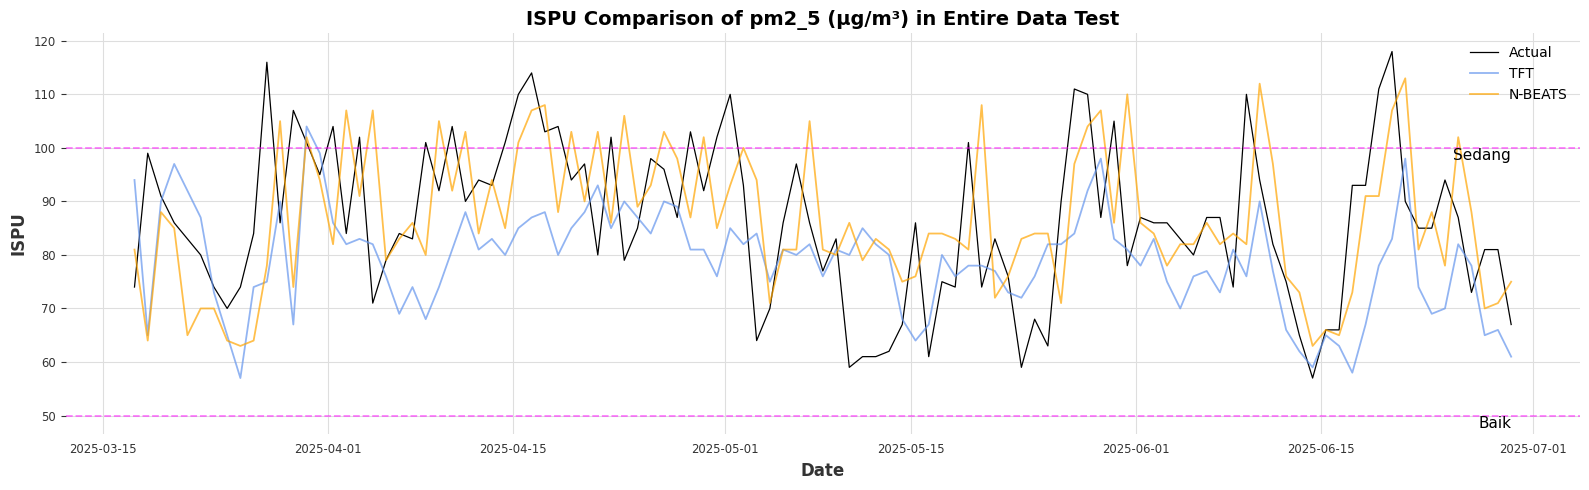

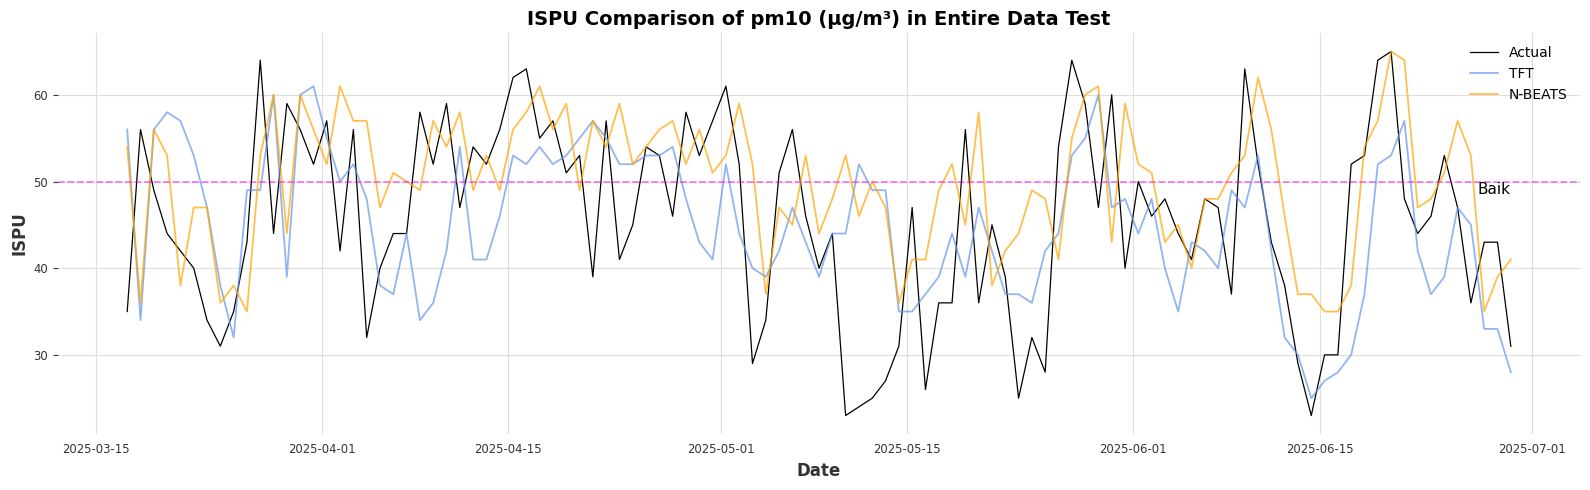

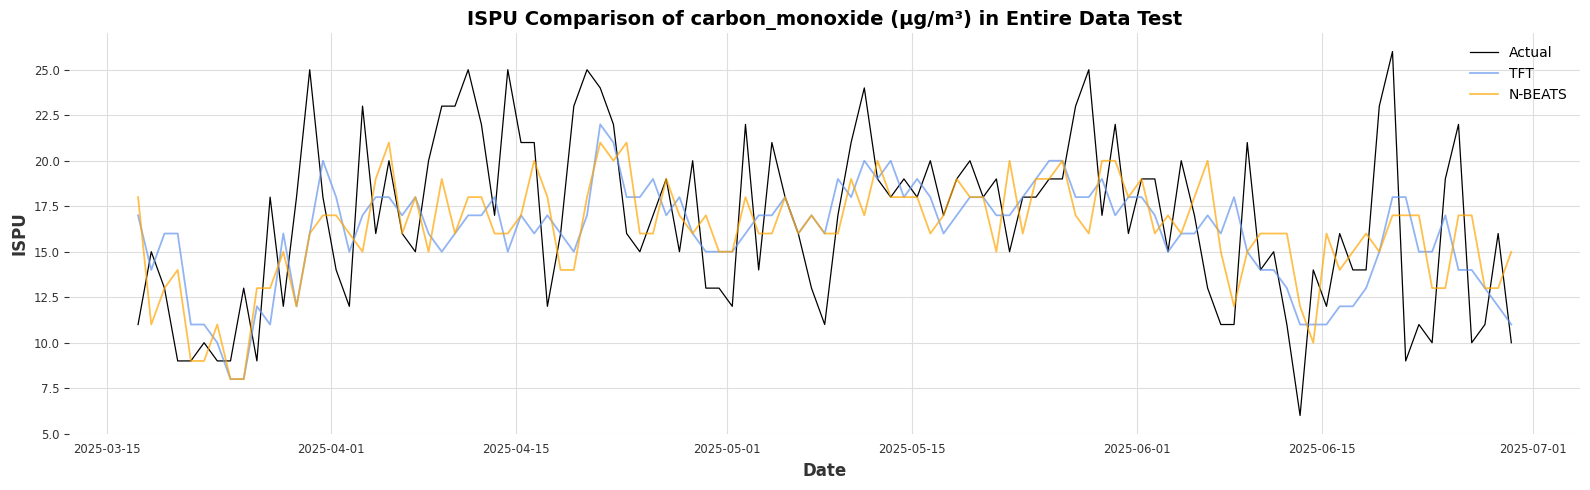

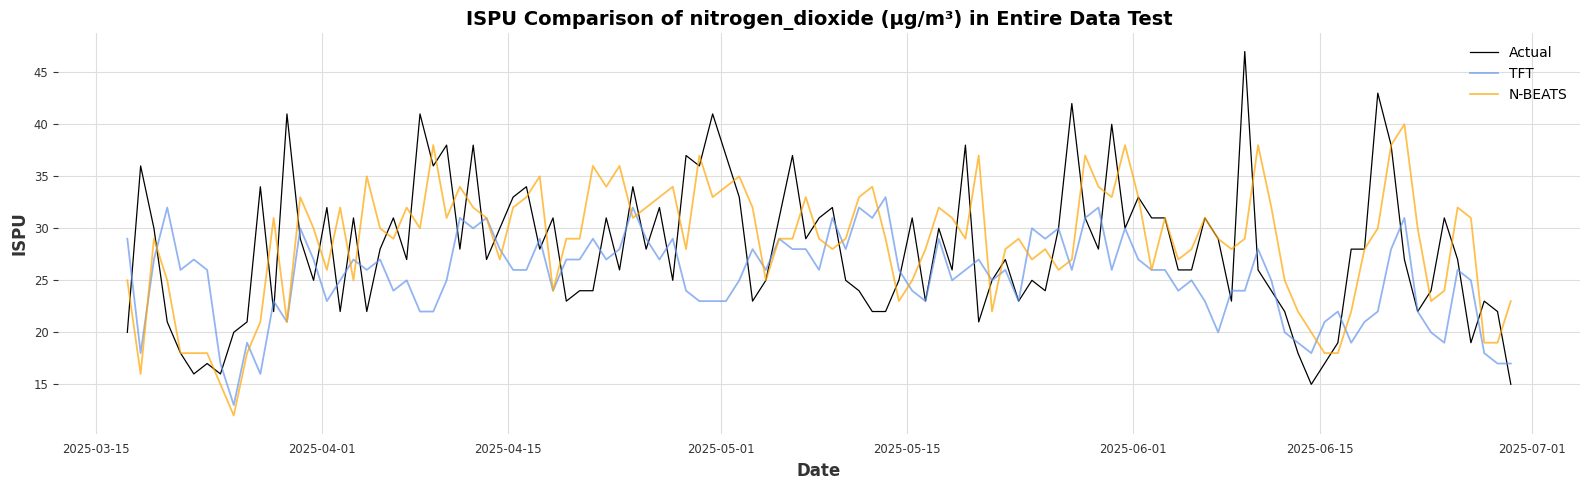

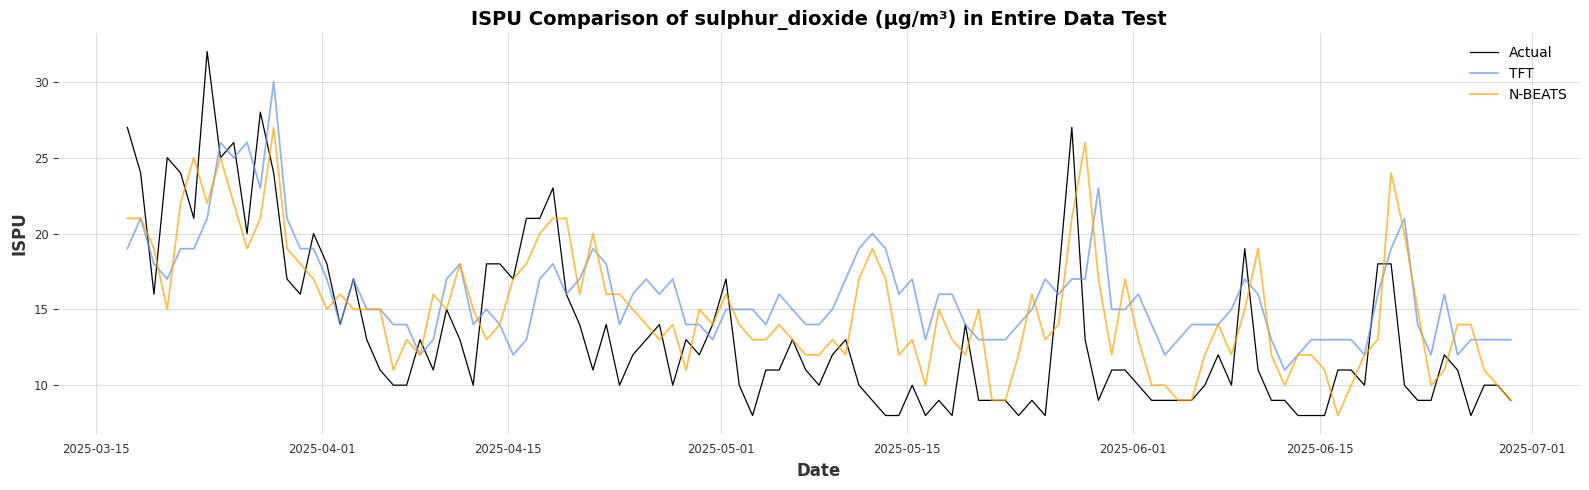

In [14]:
# Visualize ISPU results both in actual, TFT, and N-BEATS
thresholds = [50, 100, 200, 300]
threshold_labels = {
    50: 'Baik',
    100: 'Sedang',
    200: 'Tidak Sehat',
    300: 'Sangat Tidak Sehat'
}

for pollutant in ['y1', 'y2', 'y3', 'y4', 'y5']:
    fig, ax = plt.subplots(figsize=(16, 5))

    # Actual
    ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_actual'], label='Actual', linewidth=0.9, alpha=1, color='black')

    # TFT
    ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_tft_pred'], label='TFT', linewidth=1.3, alpha=0.7, color=color_variant[0])

    # N-BEATS
    ax.plot(ispu_df.index, ispu_df[f'{pollutant}_ispu_nbeats_pred'], label='N-BEATS', linewidth=1.3, alpha=0.7, color=color_variant[1])

    
    # ISPU thresholds
    max_value = max(
        ispu_df[f'{pollutant}_ispu_actual'].max(),
        ispu_df[f'{pollutant}_ispu_tft_pred'].max(),
        ispu_df[f'{pollutant}_ispu_nbeats_pred'].max()
    )
    
    for threshold in thresholds:
        if threshold <= max_value:
            ax.axhline(threshold, linestyle='--', alpha=0.5, color=color_variant[9])
            ax.text(ispu_df.index[-1], threshold, threshold_labels[threshold], fontsize=11, va='top', ha='right'
        )

    ax.set_title(f'ISPU Comparison of {col_decode[pollutant]} in Entire Data Test', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('ISPU', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, axis='x')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/ISPU_backtesting_comparison_{pollutant}.png', dpi=300)
    plt.show()

# ISPU of Future Prediction

In [15]:
# load future prediction results

## ========================= LOAD FUTURE PRED RESULTS ========================= ##
# TFT
tft_future_pred = (
    pd.read_excel('../data/predicted/tft_future_prediction_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)
print('TFT Future Pred Info:')
print(tft_future_pred.info())

# N-BEATS
nbeats_future_pred = (
    pd.read_excel('../data/predicted/nbeats_future_prediction_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)
print('\nN-BEATS Future Pred Info:')
print(nbeats_future_pred.info())

TFT Future Pred Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y1_future_pred  12 non-null     float64
 1   y2_future_pred  12 non-null     float64
 2   y3_future_pred  12 non-null     float64
 3   y4_future_pred  12 non-null     float64
 4   y5_future_pred  12 non-null     float64
dtypes: float64(5)
memory usage: 576.0 bytes
None

N-BEATS Future Pred Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12 entries, 2025-07-01 00:00:00 to 2025-07-01 11:00:00
Freq: h
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y1_future_pred  12 non-null     float64
 1   y2_future_pred  12 non-null     float64
 2   y3_future_pred  12 non-null     float64
 3   y4_future_pred  12 non-null     float64
 4   y5_future_pred 

In [16]:
# Merge with Last Backtesting Results

## ========================= TFT ========================= ##
# Load backtesting
tft_backtesting_raw = (
    pd.read_excel('../data/predicted/tft_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

# Cut to needed timestamp
tft_last_backtest = (
    tft_backtesting_raw.loc[
        '2025-06-30 09:00':'2025-06-30 23:00'
    ][[
        'y1_pred',
        'y2_pred',
        'y3_pred',
        'y4_pred',
        'y5_pred'
    ]]
)

# Change columns name to match with tft_last_backtest
tft_future = tft_future_pred.rename(columns=lambda x: x.replace('_future_pred', '_pred'))

# Cut future pred until 08:00
tft_future_9h = tft_future.loc['2025-07-01 00:00':'2025-07-01 08:00']

# Merge
tft_future = pd.concat([tft_last_backtest, tft_future_9h])

# Check
print('========================= TFT =========================')
print(tft_future.info())
print(tft_future.head(), '\n')


## ========================= N-BEATS ========================= ##
# Load backtesting
nbeats_backtesting_raw = (
    pd.read_excel('../data/predicted/nbeats_backcast_results.xlsx')
    .assign(t=lambda df: pd.to_datetime(df['t']))
    .set_index('t')
    .sort_index()
    .asfreq('h')
)

# Cut to needed timestamp
nbeats_last_backtest = (
    nbeats_backtesting_raw.loc[
        '2025-06-30 09:00':'2025-06-30 23:00'
    ][[
        'y1_pred',
        'y2_pred',
        'y3_pred',
        'y4_pred',
        'y5_pred'
    ]]
)

# Change columns name to match with nbeats_last_backtest
nbeats_future = nbeats_future_pred.rename(columns=lambda x: x.replace('_future_pred', '_pred'))

# Cut future pred until 08:00
nbeats_future_9h = nbeats_future.loc['2025-07-01 00:00':'2025-07-01 08:00']

# Merge
nbeats_future = pd.concat([nbeats_last_backtest, nbeats_future_9h])

# Check
print('========================= N-BEATS =========================')
print(nbeats_future.info())
print(nbeats_future.head())

========================= TFT =========================
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2025-06-30 09:00:00 to 2025-07-01 08:00:00
Freq: h
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   y1_pred  24 non-null     float64
 1   y2_pred  24 non-null     float64
 2   y3_pred  24 non-null     float64
 3   y4_pred  24 non-null     float64
 4   y5_pred  24 non-null     float64
dtypes: float64(5)
memory usage: 1.1 KB
None
                       y1_pred    y2_pred     y3_pred    y4_pred    y5_pred
t                                                                          
2025-06-30 09:00:00  14.234421  23.159916  788.254944  22.712475  20.862038
2025-06-30 10:00:00  14.117266  23.008018  667.726135  15.575008  17.909748
2025-06-30 11:00:00  14.148808  29.241417  438.080414  10.935756  15.210741
2025-06-30 12:00:00  14.448833  19.621531  332.976929   8.950187  13.035146
2025-06-30 13:00:00  14.16978

In [17]:
# Calculate Mean

# TFT
tft_future_daily = tft_future.mean()
print(f'TFT Future Daily Mean: \n{tft_future_daily}\n')

# N-BEATS
nbeats_future_daily = nbeats_future.mean()
print(f'N-BEATS Future Daily Mean: \n{nbeats_future_daily}')

TFT Future Daily Mean: 
y1_pred     19.478407
y2_pred     28.135912
y3_pred    763.426713
y4_pred     21.407657
y5_pred     16.256671
dtype: float64

N-BEATS Future Daily Mean: 
y1_pred     21.053382
y2_pred     27.776598
y3_pred    756.782129
y4_pred     22.266087
y5_pred     11.484879
dtype: float64


In [18]:
# Calculate ISPU for Future Prediction

tft_future_ispu = {}
nbeats_future_ispu = {}
pollutants = ['y1', 'y2', 'y3', 'y4', 'y5']

# Iterate though each pollutant
for pollutant in pollutants:

    # Calculate ISPU
    tft_future_ispu[pollutant] = calculate_ispu(tft_future_daily[f'{pollutant}_pred'], breakpoints[pollutant])
    nbeats_future_ispu[pollutant] = calculate_ispu(nbeats_future_daily[f'{pollutant}_pred'], breakpoints[pollutant])
    

# Convert to DataFrame
future_ispu_df = pd.DataFrame({
    'pollutant': pollutants,
    'ISPU_tft': [
        tft_future_ispu[p]
        for p in pollutants
    ],
    'category_ISPU_tft': [
        ispu_category(tft_future_ispu[p])
        for p in pollutants
    ],
    'ISPU_nbeats' : [
        nbeats_future_ispu[p]
        for p in pollutants
    ],
    'category_ISPU_nbeats': [
        ispu_category(nbeats_future_ispu[p])
        for p in pollutants
    ],
})

# Save results
future_ispu_df.to_excel('../reports/ispu_future.xlsx')

# Check results
future_ispu_df

,pollutant,ISPU_tft,category_ISPU_tft,ISPU_nbeats,category_ISPU_nbeats
0,y1,56,Sedang,58,Sedang
1,y2,28,Baik,28,Baik
2,y3,10,Baik,9,Baik
3,y4,13,Baik,14,Baik
4,y5,16,Baik,11,Baik


# Visualize ISPU of Future Prediction

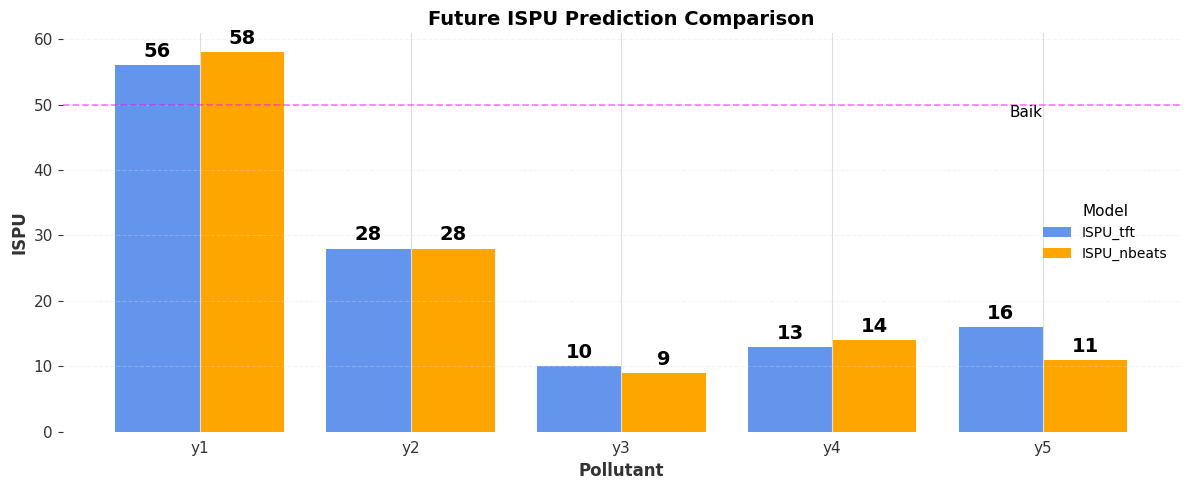

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

future_ispu_df.plot(
    x='pollutant', 
    y=['ISPU_tft', 'ISPU_nbeats'], 
    kind='bar', 
    ax=ax, 
    rot=0, 
    width=0.8, 
    color=[color_variant[0], color_variant[1]]
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=14,
        fontweight='bold'
    )

# Dynamic thresholds
thresholds = [50, 100, 200, 300]

threshold_labels = {
    50: 'Baik',
    100: 'Sedang',
    200: 'Tidak Sehat',
    300: 'Sangat Tidak Sehat'
}
max_value = future_ispu_df[['ISPU_tft', 'ISPU_nbeats']].max().max()

for threshold in thresholds:
    if threshold <= max_value:
        ax.axhline(threshold, linestyle='--', alpha=0.5, color=color_variant[9])
        ax.text(future_ispu_df.index[-1], threshold, threshold_labels[threshold], fontsize=11, va='top', ha='right')

ax.set_title('Future ISPU Prediction Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Pollutant', fontsize=12, fontweight='bold')
ax.set_ylabel('ISPU', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Model', fontsize=10, title_fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig(f'../reports/figures/ISPU_future_comparison.png', dpi=300)
plt.show()